# A, G, C, T y U — las 5 letras de la vida, dentro de un asteroide

Adenina, guanina, citosina, timina, uracilo. Las cinco bases que codifican toda la información genética de la Tierra. Un equipo las encontró **todas** en muestras del asteroide Ryugu, traídas por la sonda Hayabusa2.

> **Paper:** *"All five canonical nucleobases in samples returned from asteroid Ryugu"*
> — Oba, Koga et al. (Nature Astronomy, 2026)
> DOI: [10.1038/s41550-026-02791-z](https://doi.org/10.1038/s41550-026-02791-z)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-20-adn-bases-asteroide-ryugu/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/watch?v=8gJTRw-XgQ0)

## El contexto: ¿de dónde vienen los ingredientes de la vida?

Hay dos hipótesis sobre el origen de las moléculas prebióticas: se formaron aquí (en la Tierra primitiva) o llegaron del espacio en meteoritos y asteroides. La segunda hipótesis necesita una evidencia clave: que los asteroides **realmente contengan** las moléculas correctas.

Hasta ahora, habíamos encontrado nucleobases en meteoritos — pero los meteoritos se contaminan al caer a la Tierra. Las muestras de Ryugu son diferentes: la sonda **Hayabusa2** (JAXA) las recogió directamente del asteroide y las selló en cápsulas estériles. Y en 2024, OSIRIS-REx trajo muestras de otro asteroide: **Bennu**. Ahora podemos comparar.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
EQUILIBRIO_PU_PY = 1.0     # Ratio purina/pirimidina en equilibrio
FUENTE = 'Fuente: Oba, Koga et al. (2026), Nature Astronomy | Datos: texto del paper'

COLOR_RYUGU = '#DC2626'       # Rojo — Ryugu
COLOR_BENNU = '#059669'       # Verde — Bennu
COLOR_ORGUEIL = '#BBBBBB'     # Gris — Orgueil
COLOR_MURCHISON = '#2563EB'   # Azul — Murchison
COLOR_PURINA = '#7C3AED'      # Violeta — purinas
COLOR_PIRIMIDINA = '#D97706'  # Amber — pirimidinas

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

resumen = pd.read_csv('datos/nucleobases_resumen.csv')
ratios = pd.read_csv('datos/ratios_purina_pirimidina.csv')
uracilo = pd.read_csv('datos/uracilo_comparacion.csv')
bases = pd.read_csv('datos/nucleobases_presencia.csv')

print(f"✅ {len(resumen)} muestras extraterrestres comparadas")
print(f"✅ {len(bases)} nucleobases canónicas — todas detectadas en Ryugu")
print(f"✅ Rango: {resumen['total_nucleobases_pmol_g'].min()}-{resumen['total_nucleobases_pmol_g'].max()} pmol/g")

✅ 5 muestras extraterrestres comparadas
✅ 5 nucleobases canónicas — todas detectadas en Ryugu
✅ Rango: 507-11497 pmol/g


## ¿Cuántas moléculas de ADN hay en un asteroide?

Aquí está.

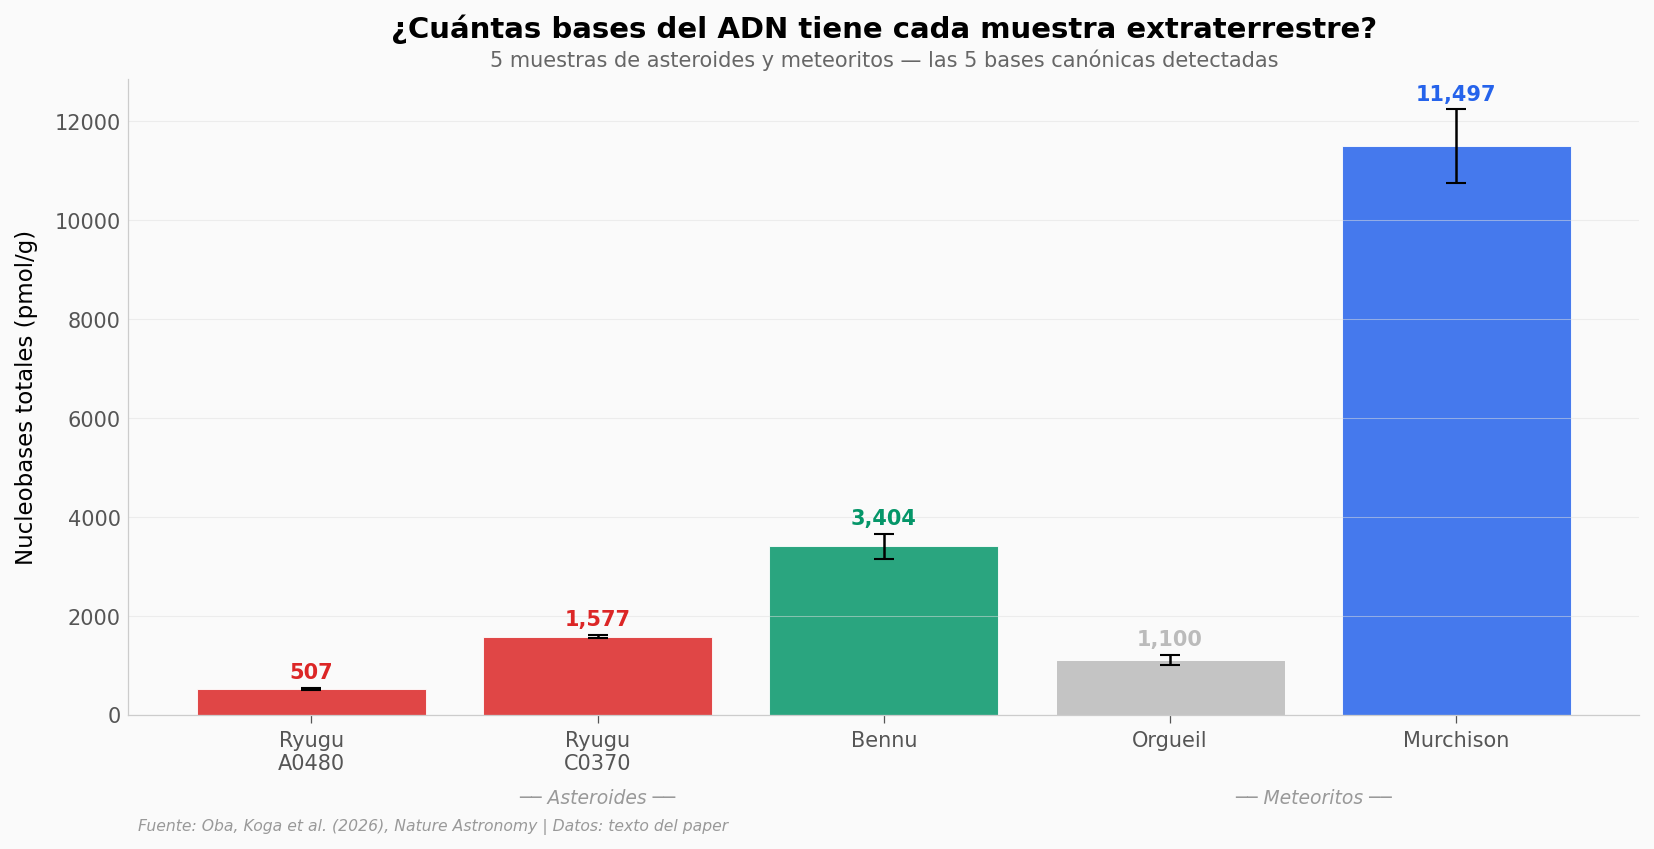

In [2]:
# Hero: concentración total de nucleobases por muestra
fig, ax = plt.subplots(figsize=(13, 5.5))

colors = [COLOR_RYUGU, COLOR_RYUGU, COLOR_BENNU, COLOR_ORGUEIL, COLOR_MURCHISON]
samples = resumen['sample'].values
conc = resumen['total_nucleobases_pmol_g'].values
err = resumen['error'].values

bars = ax.bar(range(len(samples)), conc, color=colors, alpha=0.85,
              edgecolor='white', linewidth=0.5, yerr=err, capsize=5,
              error_kw={'linewidth': 1.2, 'color': '#666666'})

# Labels on bars
for i, (c, e) in enumerate(zip(conc, err)):
    ax.text(i, c + e + 200, f'{c:,.0f}', ha='center', fontsize=10,
            fontweight='bold', color=colors[i])

ax.set_xticks(range(len(samples)))
labels = ['Ryugu\nA0480', 'Ryugu\nC0370', 'Bennu', 'Orgueil', 'Murchison']
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Nucleobases totales (pmol/g)', fontsize=11)
ax.set_title('¿Cuántas bases del ADN tiene cada muestra extraterrestre?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, '5 muestras de asteroides y meteoritos — las 5 bases canónicas detectadas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Type labels
ax.text(1, -1800, '── Asteroides ──', ha='center', fontsize=9, color='#999999', style='italic')
ax.text(3.5, -1800, '── Meteoritos ──', ha='center', fontsize=9, color='#999999', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/concentracion_total.png', dpi=200, bbox_inches='tight')
plt.show()

### El dato que salta

**Murchison** (un meteorito que cayó en Australia en 1969) tiene **22 veces** más nucleobases que Ryugu A0480. Pero Murchison lleva 55 años en la Tierra — ¿cuánto de eso es contaminación? Las muestras de Ryugu fueron selladas en el espacio y abiertas en sala limpia. Son las más limpias que tenemos.

**Bennu** (traído por OSIRIS-REx en 2023) tiene el doble que Ryugu C0370 — 3,404 vs 1,577 pmol/g. Ambos son asteroides carbonáceos tipo C, pero Bennu es más rico en nitrógeno, lo que podría explicar la diferencia.

## La receta cambia: purinas vs pirimidinas

No solo importa *cuántas* bases hay — importa la **proporción**. En el ADN terrestre, purinas y pirimidinas están en equilibrio perfecto (A=T, G=C). ¿Pasa lo mismo en el espacio?

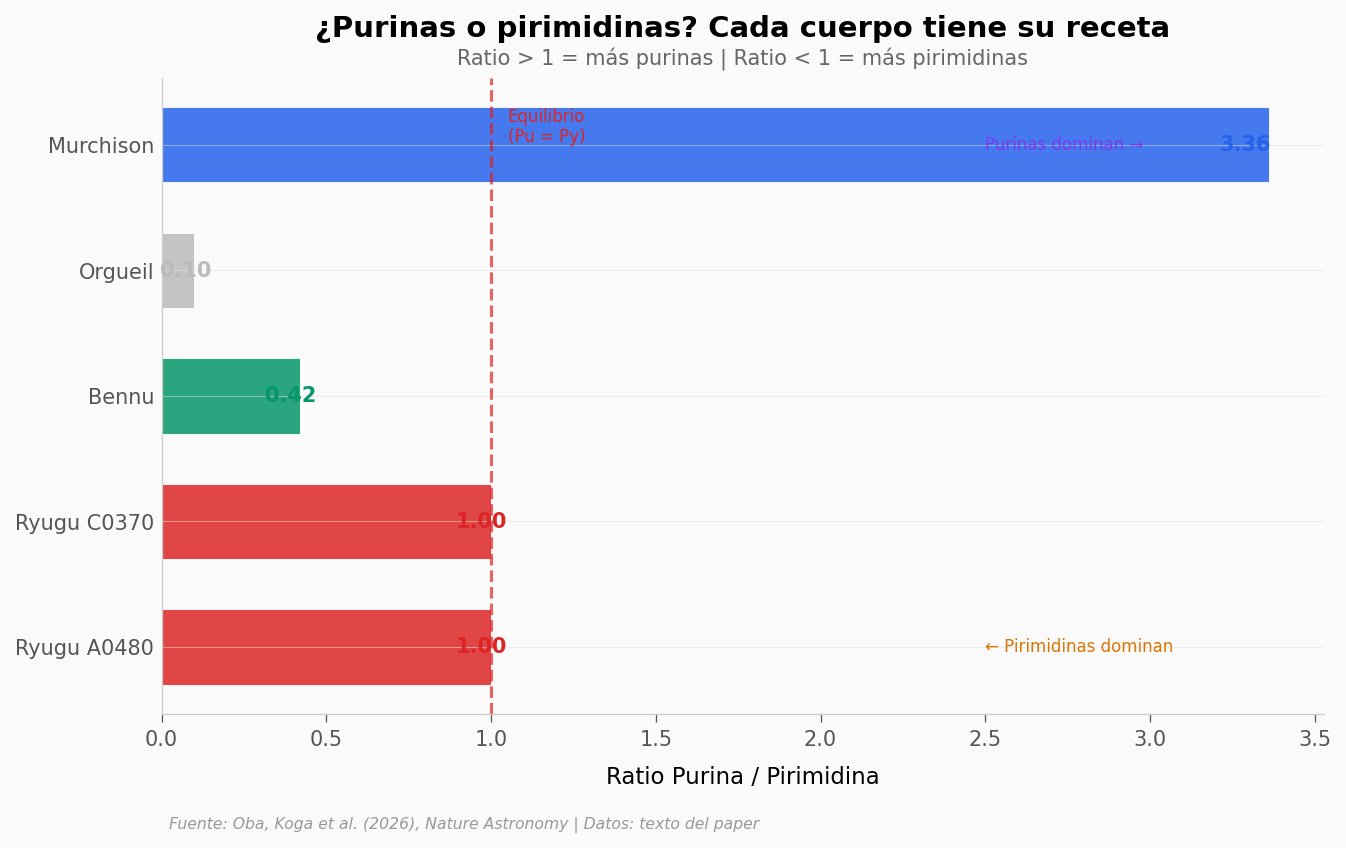

In [3]:
# Ratio Purina/Pirimidina por muestra
fig, ax = plt.subplots(figsize=(10, 5.5))

samples = ratios['sample'].values
pu_py = ratios['pu_py_ratio'].values
colors_r = [COLOR_RYUGU, COLOR_RYUGU, COLOR_BENNU, COLOR_ORGUEIL, COLOR_MURCHISON]

bars = ax.barh(range(len(samples)), pu_py, color=colors_r, alpha=0.85,
               edgecolor='white', linewidth=0.5, height=0.6)

# Equilibrium line
ax.axvline(x=EQUILIBRIO_PU_PY, color='#DC2626', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(1.05, 4.3, 'Equilibrio\n(Pu = Py)', fontsize=8, color='#DC2626', va='top')

# Value labels
for i, v in enumerate(pu_py):
    side = 'left' if v > 2 else 'right'
    offset = -0.15 if v > 2 else 0.05
    ax.text(v + offset, i, f'{v:.2f}', va='center', ha=side,
            fontsize=10, fontweight='bold', color=colors_r[i])

ax.set_yticks(range(len(samples)))
ax.set_yticklabels(samples, fontsize=10)
ax.set_xlabel('Ratio Purina / Pirimidina', fontsize=11)
ax.set_title('¿Purinas o pirimidinas? Cada cuerpo tiene su receta',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Ratio > 1 = más purinas | Ratio < 1 = más pirimidinas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Annotations
ax.text(2.5, 0, '← Pirimidinas dominan', fontsize=8, color=COLOR_PIRIMIDINA, va='center')
ax.text(2.5, 4, 'Purinas dominan →', fontsize=8, color=COLOR_PURINA, va='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ratio_purina_pirimidina.png', dpi=200, bbox_inches='tight')
plt.show()

### Tres patrones distintos

- **Ryugu:** equilibrio casi perfecto (Pu/Py ≈ 1.0). Purinas y pirimidinas en cantidades similares.
- **Murchison:** dominado por purinas (3.4x más purinas que pirimidinas). Los autores lo atribuyen a la polimerización de HCN (cianuro de hidrógeno), una ruta química que genera purinas eficientemente.
- **Bennu y Orgueil:** dominados por pirimidinas. Bennu (Pu/Py = 0.42) y Orgueil (Pu/Py = 0.10) muestran el patrón opuesto a Murchison.

Los autores sugieren que la diferencia se relaciona con la disponibilidad de **amoníaco** en cada cuerpo parental — una molécula que favorece la síntesis de pirimidinas sobre purinas.

## Las 5 letras, en contexto

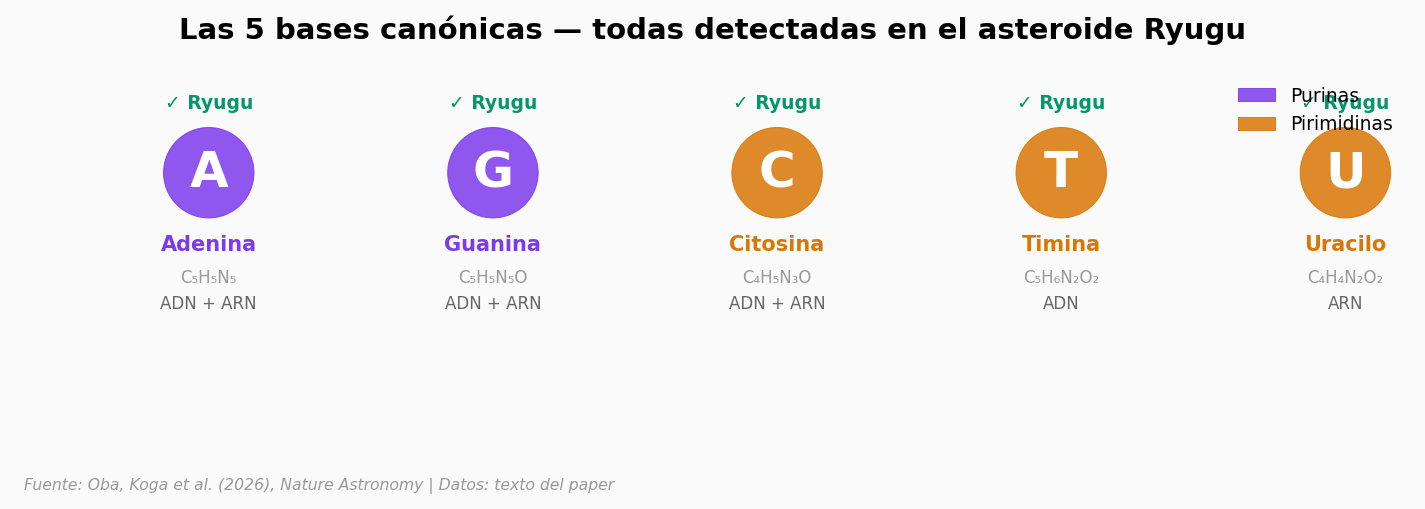

In [4]:
# Las 5 nucleobases canónicas
fig, ax = plt.subplots(figsize=(12, 4))

for i, (_, row) in enumerate(bases.iterrows()):
    color = COLOR_PURINA if row['tipo'] == 'Purina' else COLOR_PIRIMIDINA
    # Circle for each base
    circle = plt.Circle((i * 2.2 + 1, 0.5), 0.35, color=color, alpha=0.85)
    ax.add_patch(circle)
    # Letter
    letter = row['nucleobase'][0]
    ax.text(i * 2.2 + 1, 0.5, letter, ha='center', va='center',
            fontsize=24, fontweight='bold', color='white')
    # Name below
    ax.text(i * 2.2 + 1, -0.1, row['nucleobase'], ha='center', fontsize=10,
            fontweight='bold', color=color)
    # Formula
    ax.text(i * 2.2 + 1, -0.35, row['formula'], ha='center', fontsize=8, color='#999999')
    # DNA/RNA tags
    tags = []
    if row['en_ADN']:
        tags.append('ADN')
    if row['en_ARN']:
        tags.append('ARN')
    ax.text(i * 2.2 + 1, -0.55, ' + '.join(tags), ha='center', fontsize=8, color='#666666')
    # Checkmark for Ryugu
    ax.text(i * 2.2 + 1, 1.0, '✓ Ryugu', ha='center', fontsize=9, color='#059669', fontweight='bold')

ax.set_xlim(-0.5, 10.3)
ax.set_ylim(-0.8, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Las 5 bases canónicas — todas detectadas en el asteroide Ryugu',
             fontsize=14, fontweight='bold', pad=15)

from matplotlib.patches import Patch
legend = [Patch(color=COLOR_PURINA, alpha=0.85, label='Purinas'),
          Patch(color=COLOR_PIRIMIDINA, alpha=0.85, label='Pirimidinas')]
ax.legend(handles=legend, loc='upper right', fontsize=9, framealpha=0.9)

fig.text(0.13, 0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cinco_bases.png', dpi=200, bbox_inches='tight')
plt.show()

### El dato en perspectiva

Cada gramo de Ryugu contiene entre 507 y 1,577 picomoles de nucleobases — las mismas 5 moléculas que codifican toda la información genética en la Tierra. Lo confirmaron con espectrometría de masas en tándem (MS/MS) en sala limpia.

## ¿Cuánto varía entre muestras del mismo asteroide?

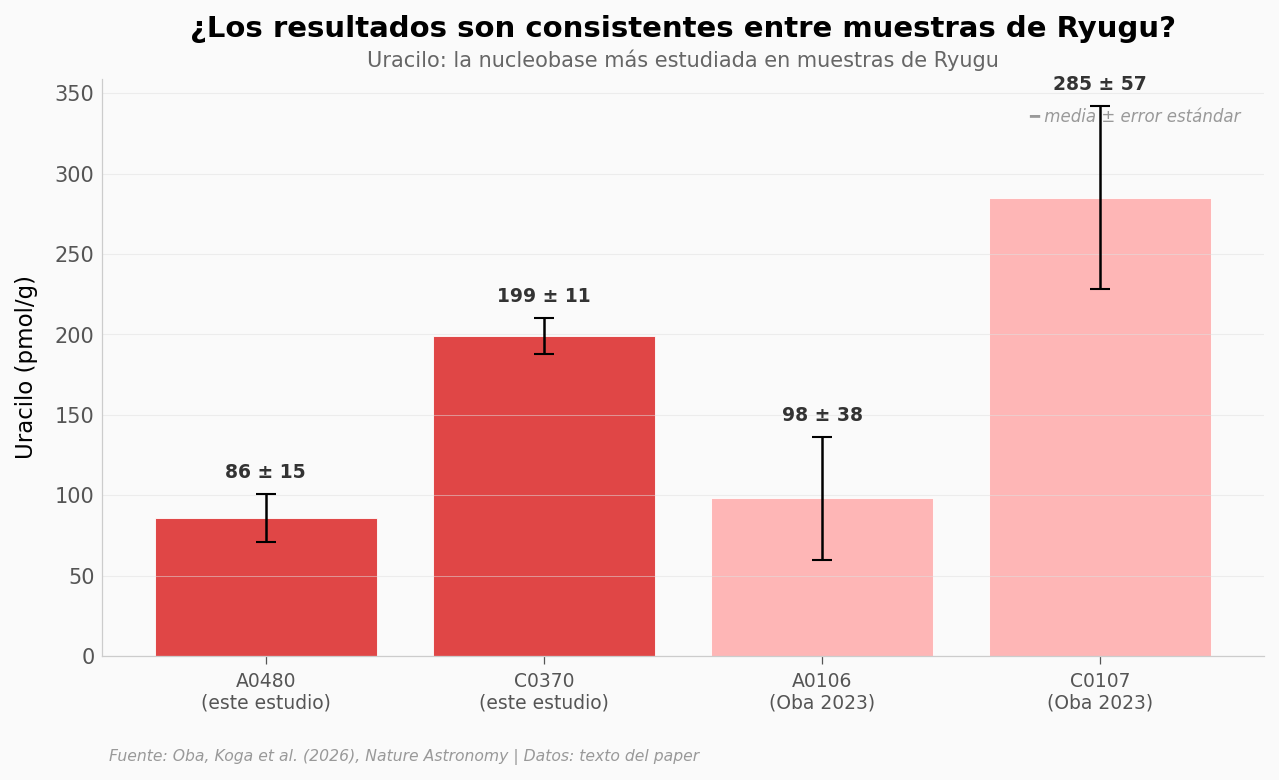

Cara A (A0480/A0106): 86 vs 98 pmol/g
Cara C (C0370/C0107): 199 vs 285 pmol/g
Ratio C/A (este estudio): 2.3x
Ratio C/A (previo): 2.9x


In [5]:
# Uracilo en diferentes muestras de Ryugu (este estudio + previo)
fig, ax = plt.subplots(figsize=(10, 5))

samples = uracilo['sample'].values
conc = uracilo['concentration_pmol_g'].values
err = uracilo['error'].values

colors_u = [COLOR_RYUGU, COLOR_RYUGU, '#FFAAAA', '#FFAAAA']  # current vs previous
bars = ax.bar(range(len(samples)), conc, color=colors_u, alpha=0.85,
              edgecolor='white', linewidth=0.5, yerr=err, capsize=5,
              error_kw={'linewidth': 1.2, 'color': '#666666'})

for i, (c, e) in enumerate(zip(conc, err)):
    ax.text(i, c + e + 10, f'{c} ± {e}', ha='center', fontsize=9,
            fontweight='bold', color='#333333')

ax.set_xticks(range(len(samples)))
labels_u = ['A0480\n(este estudio)', 'C0370\n(este estudio)', 'A0106\n(Oba 2023)', 'C0107\n(Oba 2023)']
ax.set_xticklabels(labels_u, fontsize=9)
ax.set_ylabel('Uracilo (pmol/g)', fontsize=11)
ax.set_title('¿Los resultados son consistentes entre muestras de Ryugu?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Uracilo: la nucleobase más estudiada en muestras de Ryugu',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.95, '━ media ± error estándar', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='top', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/uracilo_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()

# Stats
print(f"Cara A (A0480/A0106): {conc[0]} vs {conc[2]} pmol/g")
print(f"Cara C (C0370/C0107): {conc[1]} vs {conc[3]} pmol/g")
print(f"Ratio C/A (este estudio): {conc[1]/conc[0]:.1f}x")
print(f"Ratio C/A (previo): {conc[3]/conc[2]:.1f}x")

## Lo que los datos soportan

| Afirmación del paper | ¿Soportada? | Detalle |
|---|---|---|
| Las 5 nucleobases canónicas detectadas en Ryugu | ✅ | Confirmado por HPLC/ESI-HRMS y MS/MS en sala limpia ISO 5. Detección directa, no inferida |
| Ryugu tiene purinas y pirimidinas en proporciones similares | ✅ | Pu/Py ≈ 1.0 en ambas muestras (A0480 y C0370) |
| Murchison es rico en purinas (Pu/Py ~3.4) | ✅ | 8,861 ± 690 pmol/g purinas vs 2,636 ± 49 pirimidinas → Pu/Py = 3.36 |
| El amoníaco modula el ratio Pu/Py | ⚠️ | El paper reporta correlación negativa (r² = 0.89, n = 4, p ≈ 0.06 — no significativo a α = 0.05). El paper usa "suggest" — es una hipótesis, no un hecho establecido |
| Los asteroides carbonáceos aportaron moléculas prebióticas a la Tierra | ⚠️ | El paper dice "reinforces the hypothesis" — la detección es real, la interpretación prebiótica es plausible pero no demostrada por estos datos solos |
| C0370 tiene ~3x más nucleobases que A0480 | ✅ | 1,577 / 507 = 3.1x. Refleja heterogeneidad dentro del asteroide |

> **Limitaciones:** (1) Las concentraciones de Orgueil (~1,100 pmol/g) son estimaciones del texto, no valores de tabla directos. (2) Los ratios Pu/Py de Ryugu (~1.0) son aproximados — el paper dice "nearly equal" sin dar el valor exacto. (3) La comparación incluye muestras analizadas por diferentes grupos con diferentes métodos (Murchison: Callahan 2011; Bennu: Aponte 2025). (4) n = 4 muestras para la correlación amoníaco-Pu/Py es demasiado bajo para conclusiones firmes.

> **Nota sobre certeza:** La **detección** de nucleobases es un hecho analítico confirmado (MS/MS). La **interpretación** sobre su origen y rol prebiótico usa lenguaje condicional: "may have formed", "indicate", "reinforces the hypothesis". El notebook respeta esa distinción.

## Ahora tú

1. **¿Cuánto varía el uracilo entre caras del asteroide?** El ratio C/A es ~2.3x en este estudio y ~2.9x en el previo. ¿Es la cara C consistentemente más rica?

2. **¿Murchison es un outlier?** Tiene 22x más nucleobases que Ryugu A0480. ¿Es por contaminación terrestre (55 años en la Tierra) o por la química del cuerpo parental (CM vs CI)?

3. **Prueba calcular la masa total de nucleobases** en todo el asteroide Ryugu (~450 millones de toneladas). Si la concentración promedio es ~1,000 pmol/g, ¿cuántos gramos de nucleobases hay?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántas nucleobases hay en todo Ryugu?
masa_ryugu_kg = 4.5e11  # ~450 millones de toneladas
concentracion_pmol_g = 1000  # promedio entre A0480 y C0370

# 1 pmol = 1e-12 mol
masa_molar_promedio = 130  # g/mol (promedio de las 5 bases: A=135, G=151, C=111, T=126, U=112)

total_mol = concentracion_pmol_g * 1e-12 * masa_ryugu_kg * 1e3  # g → mol
total_g = total_mol * masa_molar_promedio

print(f"Masa de Ryugu: {masa_ryugu_kg:.1e} kg")
print(f"Concentración promedio: {concentracion_pmol_g} pmol/g")
print(f"Total nucleobases: {total_mol:.1e} mol = {total_g:.1f} g = {total_g/1000:.3f} kg")
print(f"\nEso es {total_g/1000:.1f} kg — casi 60 toneladas de letras del ADN flotando en el espacio.")
print(f"Y son {total_mol * 6.022e23:.1e} moléculas.")

Masa de Ryugu: 4.5e+11 kg
Concentración promedio: 1000 pmol/g
Total nucleobases: 4.5e+05 mol = 58500000.0 g = 58500.000 kg

Eso es 58500.0 kg — casi 60 toneladas de letras del ADN flotando en el espacio.
Y son 2.7e+29 moléculas.


---

## Créditos

- **Paper:** Oba, Koga et al. (2026). *"All five canonical nucleobases in samples returned from asteroid Ryugu."* Nature Astronomy. DOI: [10.1038/s41550-026-02791-z](https://doi.org/10.1038/s41550-026-02791-z)
- **Datos:** Concentraciones extraídas del texto del paper y Table 1. Datos crudos de espectrometría (XLSX) en Supplementary Materials.
- **Código:** [GitHub — Ciencia a Mordiscos / El Lab](https://github.com/Ciencia-a-Mordiscos/lab)
- **Licencia:** CC-BY-4.0